<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Goal" data-toc-modified-id="Goal-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Goal</a></span></li><li><span><a href="#Var" data-toc-modified-id="Var-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var</a></span></li><li><span><a href="#Init" data-toc-modified-id="Init-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Init</a></span></li><li><span><a href="#Load" data-toc-modified-id="Load-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Load</a></span><ul class="toc-item"><li><span><a href="#Metadata" data-toc-modified-id="Metadata-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Metadata</a></span></li><li><span><a href="#Counts" data-toc-modified-id="Counts-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Counts</a></span></li><li><span><a href="#Alpha-div" data-toc-modified-id="Alpha-div-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Alpha div</a></span></li></ul></li><li><span><a href="#Format" data-toc-modified-id="Format-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Format</a></span><ul class="toc-item"><li><span><a href="#Overlap" data-toc-modified-id="Overlap-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Overlap</a></span></li><li><span><a href="#Merging" data-toc-modified-id="Merging-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Merging</a></span></li></ul></li><li><span><a href="#ML-settings" data-toc-modified-id="ML-settings-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>ML settings</a></span><ul class="toc-item"><li><span><a href="#functions" data-toc-modified-id="functions-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>functions</a></span></li></ul></li><li><span><a href="#Westernization" data-toc-modified-id="Westernization-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Westernization</a></span><ul class="toc-item"><li><span><a href="#RF" data-toc-modified-id="RF-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>RF</a></span><ul class="toc-item"><li><span><a href="#Performance" data-toc-modified-id="Performance-7.1.1"><span class="toc-item-num">7.1.1&nbsp;&nbsp;</span>Performance</a></span></li></ul></li></ul></li><li><span><a href="#Gender" data-toc-modified-id="Gender-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Gender</a></span><ul class="toc-item"><li><span><a href="#RF" data-toc-modified-id="RF-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>RF</a></span><ul class="toc-item"><li><span><a href="#Performance" data-toc-modified-id="Performance-8.1.1"><span class="toc-item-num">8.1.1&nbsp;&nbsp;</span>Performance</a></span></li></ul></li></ul></li><li><span><a href="#Disease" data-toc-modified-id="Disease-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Disease</a></span><ul class="toc-item"><li><span><a href="#RF" data-toc-modified-id="RF-9.1"><span class="toc-item-num">9.1&nbsp;&nbsp;</span>RF</a></span><ul class="toc-item"><li><span><a href="#Performance" data-toc-modified-id="Performance-9.1.1"><span class="toc-item-num">9.1.1&nbsp;&nbsp;</span>Performance</a></span></li></ul></li></ul></li><li><span><a href="#Performance-summary" data-toc-modified-id="Performance-summary-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Performance summary</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Writing-table" data-toc-modified-id="Writing-table-10.0.0.1"><span class="toc-item-num">10.0.0.1&nbsp;&nbsp;</span>Writing table</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#sessionInfo" data-toc-modified-id="sessionInfo-11"><span class="toc-item-num">11&nbsp;&nbsp;</span>sessionInfo</a></span></li></ul></div>

# Goal

* ML with all previously computed alpha diversity measures:
  * shannon & faith PD
  * MPD & MNTD
  * functional richness and evenness

# Var

In [1]:
work_dir = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/ML/'

# sample metadata
## filtered
metadata_filt_file = file.path(work_dir, 'CurMetDat_metadata_filt-n1846.tsv')
## all 
base_in_dir = '/ebio/abt3_projects/small_projects/nyoungblut/public_data_retireval/'
metadata_file = file.path(base_in_dir, 'CurMetDat-metagenomes', 'files', 'metadata', 'Filtered_CurMetDat_f.tsv')

# bracken counts
brk_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/bracken_filt.qs'

# alpha diversity
## standard
alpha_div_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/alpha_div_cog-pfam.tsv'
## eco-phy
mpd_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/MPD.tsv'
mntd_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/MNTD.tsv'
## FD
fd_trt_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/Traitar_FD_m-min.RDS'
fd_cog_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/cogcat_FD_m-min.RDS'

# params
threads = 8
seed = 28271

# Init

In [2]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(tidytable)
library(doParallel)
library(LeyLabRMisc)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘tidytable’


The following object is masked from ‘package:stats’:

    dt


Loading required package: foreach

Loading required package: iterators

Loading required package: parallel



In [3]:
library(Boruta)
library(mlr)
library(randomForest)
library(parallelMap)

Loading required package: ParamHelpers

'mlr' is in maintenance mode since July 2019. Future development
efforts will go into its successor 'mlr3' (<https://mlr3.mlr-org.com>).

randomForest 4.6-14

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine




In [4]:
setDTthreads(threads)
make_dir(work_dir)
set.seed(seed)
df.dims()

Directory already exists: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/ML/ 


In [5]:
# custom boruta filter
mlr_boruta_filter()

Filter: 'boruta.filter'
Packages: ''
Supported tasks: classif,regr
Supported features: numerics,factors,ordered

# Load

## Metadata

In [6]:
# sample metadata
meta = Fread(metadata_file) %>%
    mutate.(Sample = gsub('-', '.', Sample)) %>%
    filter.(number_reads >= 5e5)
meta

Warning message in require_bit64_if_needed(ans):
“Some columns are type 'integer64' but package bit64 is not installed. Those columns will print as strange looking floating point data. There is no need to reload the data. Simply install.packages('bit64') to obtain the integer64 print method and print the data again.”


dataset_name,Sample,subjectID,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
AsnicarF_2017,MV_FEM1_t1Q14,MV_FEM1,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
AsnicarF_2017,MV_FEM2_t1Q14,MV_FEM2,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
ZellerG_2014,CCIS82944710ST.20.0,FR-730,stool,NA,control,healthy,38,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
ZellerG_2014,CCIS93040568ST.20.0,FR-682,stool,NA,control,healthy,65,adult,male,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


## Counts

In [7]:
# Bracken count table
brk = qs::qread(brk_file, nthreads=threads) %>%
    mutate.(name = gsub(' ', '_', name))
brk 

dataset,name,taxonomy_id,taxonomy_lvl,Domain,Phylum,Class,Order,Family,Genus,Species,Sample,Abundance
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CosteaPI_2017,s__Caecibacter_massiliensis,108259,S,Bacteria,Firmicutes_C,Negativicutes,Veillonellales,Megasphaeraceae,Caecibacter,Caecibacter massiliensis,halbarad.11.0.0,0
CosteaPI_2017,s__UBA1777_sp002350825,178550,S,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Oscillospiraceae,UBA1777,UBA1777 sp002350825,halbarad.11.0.0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
YuJ_2015,s__Serratia_grimesii,121568,S,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Serratia,Serratia grimesii,SZAXPI017592.142,0
YuJ_2015,s__Bacteroides_A_sp002161565,119189,S,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides_A,Bacteroides_A sp002161565,SZAXPI017592.142,0


## Alpha div

In [8]:
# alpha div
alpha_div = Fread(alpha_div_file)
colnames(alpha_div) = gsub('pd_', 'PD_', colnames(alpha_div))
alpha_div

Sample,nobs,shannon,simpson,pielou,PD_phy,PD_trt,PD_cog,PD_cogcat,PD_pfam,PD_pfamcat
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,232,3.888802,0.9507426,0.4757117,55.94272,43.94092,73.48643,28.29848,34.96796,21.56298
A02_01_1FE,176,3.418777,0.8891672,0.4182143,40.24502,31.18437,50.07578,20.65005,23.78966,14.55168
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,272,3.612832,0.8932187,0.4419526,53.11264,46.47031,88.09736,34.25477,41.73731,25.03576
scavenger.11.60.0,210,3.891553,0.9557596,0.4760482,37.27697,35.63946,64.59389,22.62152,29.89625,18.25607


In [9]:
# MPD
mpd = Fread(mpd_file) %>%
    pivot_wider.(names_from=tree, values_from=MPD) 
colnames(mpd)[2:ncol(mpd)] = gsub('(phy_|_phy)', '', colnames(mpd)[2:ncol(mpd)])
colnames(mpd)[2:ncol(mpd)] = gsub('^', 'MPD_', colnames(mpd)[2:ncol(mpd)])
colnames(mpd)[2] = c('MPD_phy')
mpd

Sample,MPD_phy,MPD_cog,MPD_cogcat,MPD_pfam,MPD_pfamcat,MPD_trt
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,-10.753480,-3.000726,-1.470243,-15.327176,-7.664077,-11.734307
A02_01_1FE,-5.395721,-3.828385,-1.231622,-9.167519,-7.014834,-4.189331
⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,-23.75160,-2.681203,-1.736976,-18.12262,-8.263948,-22.69756
scavenger.11.60.0,-21.47558,-7.025269,-2.118286,-29.88087,-16.395681,-23.29352


In [10]:
# MNTD
mntd = Fread(mntd_file) %>%
    pivot_wider.(names_from=tree, values_from=MNTD) 
colnames(mntd)[2:ncol(mntd)] = gsub('(phy_|_phy)', '', colnames(mntd)[2:ncol(mntd)])
colnames(mntd)[2:ncol(mntd)] = gsub('^', 'MNTD_', colnames(mntd)[2:ncol(mntd)])
colnames(mntd)[2] = c('MNTD_phy')
mntd

Sample,MNTD_phy,MNTD_cog,MNTD_cogcat,MNTD_pfam,MNTD_pfamcat,MNTD_trt
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,-7.350849,-8.628884,-4.608447,-13.52691,-13.7062,-9.092287
A02_01_1FE,-5.558870,-9.454823,-5.622129,-13.66279,-14.9171,-9.877560
⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,-10.315815,-10.76523,-4.972554,-14.53673,-15.59144,-12.57478
scavenger.11.60.0,-8.516701,-11.95570,-5.918881,-15.39147,-15.12150,-12.39195


In [11]:
## FD
fd_trt = readRDS(fd_trt_file)
v = c('FRic', 'FEve', 'FDiv', 'FDis', 'RaoQ') 
fd_trt = v %>%
    lapply(function(x) fd_trt[[x]] %>% as.data.frame) %>%
    do.call(cbind, .)
           
x = c('FRic', 'FEve', 'FDiv', 'FDis', 'RaoQ') 
colnames(fd_trt) = gsub('^', 'trt_', x)
colnames(fd_trt) = gsub('(.+)_(.+)', '\\2_\\1', colnames(fd_trt))
fd_trt$Sample = rownames(fd_trt)
fd_trt

,FRic_trt,FEve_trt,FDiv_trt,FDis_trt,RaoQ_trt,Sample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
A01_02_1FE,405.3489,0.6305880,0.7290097,6.973794,52.75731,A01_02_1FE
A02_01_1FE,315.4350,0.5794583,0.8070891,6.341048,45.50104,A02_01_1FE
⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,243.02318,0.5773991,0.8391111,5.956270,37.65335,nHMX11726
scavenger.11.60.0,99.81046,0.5403505,0.5274329,5.515369,31.73968,scavenger.11.60.0


In [12]:
## FD
fd_cog = readRDS(fd_cog_file)
v = c('FRic', 'FEve', 'FDiv', 'FDis', 'RaoQ') 
fd_cog = v %>%
    lapply(function(x) fd_cog[[x]] %>% as.data.frame) %>%
    do.call(cbind, .)
           
x = c('FRic', 'FEve', 'FDiv', 'FDis', 'RaoQ') 
colnames(fd_cog) = gsub('^', 'cogcat_', x)
colnames(fd_cog) = gsub('(.+)_(.+)', '\\2_\\1', colnames(fd_cog))
fd_cog$Sample = rownames(fd_cog)
fd_cog

,FRic_cogcat,FEve_cogcat,FDiv_cogcat,FDis_cogcat,RaoQ_cogcat,Sample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
A01_02_1FE,0.01801202,0.6300578,0.8226669,0.1390624,0.02458852,A01_02_1FE
A02_01_1FE,0.01696774,0.6244829,0.8734180,0.1164369,0.01988324,A02_01_1FE
⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,0.01740735,0.6201435,0.6753169,0.06340579,0.005202252,nHMX11726
scavenger.11.60.0,0.01272163,0.5382319,0.7079228,0.07027430,0.005815837,scavenger.11.60.0


# Format

## Overlap

In [13]:
overlap(alpha_div$Sample, meta$Sample)

intersect(x,y): 3348 
setdiff(x,y): 9 
setdiff(y,x): 234 
union(x,y): 3591 


In [14]:
overlap(mpd$Sample, meta$Sample)

intersect(x,y): 3348 
setdiff(x,y): 0 
setdiff(y,x): 234 
union(x,y): 3582 


In [15]:
overlap(mntd$Sample, meta$Sample)

intersect(x,y): 3348 
setdiff(x,y): 0 
setdiff(y,x): 234 
union(x,y): 3582 


In [16]:
overlap(fd_trt$Sample, meta$Sample)

intersect(x,y): 3348 
setdiff(x,y): 9 
setdiff(y,x): 234 
union(x,y): 3591 


In [17]:
overlap(fd_cog$Sample, meta$Sample)

intersect(x,y): 3348 
setdiff(x,y): 9 
setdiff(y,x): 234 
union(x,y): 3591 


## Merging

In [27]:
feats = meta %>%
    select.(dataset_name, Sample, age, BMI, gender, westernized, disease) %>%
    mutate.(disease = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    inner_join.(alpha_div, c('Sample')) %>%
    inner_join.(mpd, c('Sample')) %>%
    inner_join.(mntd, c('Sample')) %>%
    inner_join.(fd_trt, c('Sample')) %>%
    inner_join.(fd_cog, c('Sample')) 
feats

dataset_name,Sample,age,BMI,gender,westernized,disease,nobs,shannon,simpson,⋯,FRic_trt,FEve_trt,FDiv_trt,FDis_trt,RaoQ_trt,FRic_cogcat,FEve_cogcat,FDiv_cogcat,FDis_cogcat,RaoQ_cogcat
<chr>,<chr>,<int>,<dbl>,<chr>,<lgl>,<chr>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PasolliE_2018,A01_02_1FE,NA,NA,NA,FALSE,healthy,232,3.888802,0.9507426,⋯,405.3489,0.6305880,0.7290097,6.973794,52.75731,0.01801202,0.6300578,0.8226669,0.1390624,0.02458852
PasolliE_2018,A02_01_1FE,NA,NA,NA,FALSE,healthy,176,3.418777,0.8891672,⋯,315.4350,0.5794583,0.8070891,6.341048,45.50104,0.01696774,0.6244829,0.8734180,0.1164369,0.01988324
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
LiJ_2017,nHMX11726,NA,NA,NA,TRUE,healthy,272,3.612832,0.8932187,⋯,243.02318,0.5773991,0.8391111,5.956270,37.65335,0.01740735,0.6201435,0.6753169,0.06340579,0.005202252
CosteaPI_2017,scavenger.11.60.0,NA,NA,NA,TRUE,healthy,210,3.891553,0.9557596,⋯,99.81046,0.5403505,0.5274329,5.515369,31.73968,0.01272163,0.5382319,0.7079228,0.07027430,0.005815837


# ML settings

In [28]:
conda_env = '/ebio/abt3_projects/Anxiety_Twins_Metagenomes/envs/tidyverse-ML2'
resources = list(h_rt = '00:59:00',
                 h_vmem = '12G',
                 conda.env = conda_env)

In [29]:
# list of all performances
perf_res = list()

## functions

In [30]:
# classifier performance
cls_perf = function(res){
    cat('--AUC--\n')
    res$measures.test$auc %>% summary %>% print
    cat('--F1--\n')
    res$measures.test$f1 %>% summary %>% print
    cat('--plot--\n')
    p = res$measures.test %>%
        pivot_longer.(cols=c(-iter), names_to='metric', values_to='value') %>%
        ggplot(aes(metric, value)) +
        geom_boxplot() +
        theme_bw()  
    p.dims(4,2.5)
    plot(p)
}

In [31]:
#' feature importance
merge_feat_imp = function(iter, feat_imp){
    res = feat_imp[[iter]]$res
    res$iter = iter
    return(res)  
}

get_feat_imp = function(res, threads){
    doParallel::registerDoParallel(threads)
    feat_imp = res$models %>%
        plyr::llply(function(x) getFeatureImportance(x)$res,
                    .parallel=TRUE) %>%
        rbindlist(use.names=TRUE, idcol='cv_rep')
    return(feat_imp)
}

In [32]:
# plotting most important features
plot_feat_imp = function(feat_imp, max_rank = 50, y_offset=-0.01){
    p = feat_imp %>%
        mutate.(rank = row_number(-importance),
                .by=c('cv_rep')) %>%
        mutate.(mean_rank = mean(rank),
                .by=c(variable)) %>%
        filter.(mean_rank < max_rank) %>%
        mutate.(measure_type = case_when.(grepl('MPD|MNTD', variable) ~ 'eco-phy',
                                       grepl('FEve|FRic|FDis|RaoQ|FDiv', variable) ~ 'func. div.',
                                       TRUE ~ 'alpha div.')) %>%
        mutate.(data_type = case_when.(grepl('phy', variable) ~ 'phylogeny',
                                       grepl('trt', variable) ~ 'trait',
                                       grepl('pfam|cog', variable) ~ 'COG/Pfam',
                                       TRUE ~ 'no tree')) %>%
        mutate.(variable = variable %>% reorder(-mean_rank)) %>%
        ggplot(aes(variable, importance)) +
        geom_point(aes(y=y_offset, fill=data_type), pch=22, size=4) +
        geom_boxplot(aes(color=measure_type)) +
        scale_color_discrete('Measure') +
        scale_fill_discrete('Tree') +
        labs(x='Feature', y='Importance') +
        theme_bw() +
        theme(
            axis.text.x = element_text(angle=45, hjust=1)
        ) +
        coord_flip()
    return(p)
}

# Westernization

In [33]:
target = 'westernized'
measures = list(auc, acc, mcc, f1)
cv_iters = 5

In [34]:
# formatting
feats_f = feats %>%
    select.(-age, -BMI, -gender, -disease) %>%
    filter.(!is.na(westernized)) %>%
    as.data.frame
rownames(feats_f) = feats_f$Sample
feats_f$Sample = NULL
feats_f

,dataset_name,westernized,nobs,shannon,simpson,pielou,PD_phy,PD_trt,PD_cog,PD_cogcat,⋯,FRic_trt,FEve_trt,FDiv_trt,FDis_trt,RaoQ_trt,FRic_cogcat,FEve_cogcat,FDiv_cogcat,FDis_cogcat,RaoQ_cogcat
,<chr>,<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,PasolliE_2018,FALSE,232,3.888802,0.9507426,0.4757117,55.94272,43.94092,73.48643,28.29848,⋯,405.3489,0.6305880,0.7290097,6.973794,52.75731,0.01801202,0.6300578,0.8226669,0.1390624,0.02458852
A02_01_1FE,PasolliE_2018,FALSE,176,3.418777,0.8891672,0.4182143,40.24502,31.18437,50.07578,20.65005,⋯,315.4350,0.5794583,0.8070891,6.341048,45.50104,0.01696774,0.6244829,0.8734180,0.1164369,0.01988324
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,LiJ_2017,TRUE,272,3.612832,0.8932187,0.4419526,53.11264,46.47031,88.09736,34.25477,⋯,243.02318,0.5773991,0.8391111,5.956270,37.65335,0.01740735,0.6201435,0.6753169,0.06340579,0.005202252
scavenger.11.60.0,CosteaPI_2017,TRUE,210,3.891553,0.9557596,0.4760482,37.27697,35.63946,64.59389,22.62152,⋯,99.81046,0.5403505,0.5274329,5.515369,31.73968,0.01272163,0.5382319,0.7079228,0.07027430,0.005815837


In [35]:
# summary
## target
feats_f[,target] %>% table
## all features
feats_f %>% summary

.
FALSE  TRUE 
  518  2830 

 dataset_name       westernized          nobs          shannon      
 Length:3348        Mode :logical   Min.   : 23.0   Min.   :0.7248  
 Class :character   FALSE:518       1st Qu.:237.0   1st Qu.:3.6469  
 Mode  :character   TRUE :2830      Median :279.0   Median :4.1193  
                                    Mean   :274.2   Mean   :3.9909  
                                    3rd Qu.:317.0   3rd Qu.:4.4544  
                                    Max.   :484.0   Max.   :5.2184  
    simpson           pielou            PD_phy           PD_trt      
 Min.   :0.2267   Min.   :0.08866   Min.   : 8.175   Min.   : 5.864  
 1st Qu.:0.9290   1st Qu.:0.44612   1st Qu.:43.740   1st Qu.:40.002  
 Median :0.9598   Median :0.50391   Median :53.459   Median :48.288  
 Mean   :0.9390   Mean   :0.48820   Mean   :53.365   Mean   :47.316  
 3rd Qu.:0.9748   3rd Qu.:0.54490   3rd Qu.:62.845   3rd Qu.:55.590  
 Max.   :0.9905   Max.   :0.63836   Max.   :98.112   Max.   :86.070  
     PD_cog          PD_cog

## RF

In [39]:
# creating mlr task
tsk = makeClassifTask(data = feats_f %>% select(-dataset_name), 
                      target = target, 
                      blocking = feats_f$dataset_name %>% as.factor)
tsk

Supervised task: feats_f %>% select(-dataset_name)
Type: classif
Target: westernized
Observations: 3348
Features:
   numerics     factors     ordered functionals 
         32           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: TRUE
Has coordinates: FALSE
Classes: 2
FALSE  TRUE 
  518  2830 
Positive class: FALSE

In [40]:
# what sampling rate to use?
rate = 1/5
undersample(tsk, rate = rate)

Supervised task: feats_f %>% select(-dataset_name)
Type: classif
Target: westernized
Observations: 1084
Features:
   numerics     factors     ordered functionals 
         32           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: TRUE
Has coordinates: FALSE
Classes: 2
FALSE  TRUE 
  518   566 
Positive class: FALSE

In [41]:
## feature selection (wrapping the RF learner)
lrn = makeLearner('classif.cforest', predict.type = 'prob', ntree = 500)
lrn

Learner classif.cforest from package party
Type: classif
Name: Random forest based on conditional inference trees; Short name: cforest
Class: classif.cforest
Properties: twoclass,multiclass,prob,factors,numerics,ordered,weights,missings,featimp
Predict-Type: prob
Hyperparameters: ntree=500


In [42]:
# sampling
lrn = makeUndersampleWrapper(lrn, usw.rate = rate)
lrn

Learner classif.cforest.undersampled from package mlr,party
Type: classif
Name: ; Short name: 
Class: UndersampleWrapper
Properties: numerics,factors,ordered,missings,weights,prob,twoclass,multiclass,featimp
Predict-Type: prob
Hyperparameters: ntree=500,usw.rate=0.2


In [44]:
## evaluation 
parallelStartMulticore(cpus=threads, level = 'mlr.resample')
rs = makeResampleDesc('CV', iters = cv_iters)
res = resample(lrn, tsk, 
               resampling = rs,  
               models = TRUE,
               measures = measures)
parallelStop()

Warning message in parallelStart(mode = MODE_MULTICORE, cpus = cpus, level = level, :
“Parallelization was not stopped, doing it now.”
Stopped parallelization. All cleaned up.

Starting parallelization in mode=multicore with cpus=8.

Resampling: cross-validation

Measures:             auc       acc       mcc       f1        

Mapping in parallel: mode = multicore; level = mlr.resample; cpus = 8; elements = 5.




Aggregated Result: auc.test.mean=0.9194100,acc.test.mean=0.8369252,mcc.test.mean=0.5578869,f1.test.mean=0.6181239




Stopped parallelization. All cleaned up.



### Performance

In [45]:
df.dims(30)
perf_res[['westernized_RF']] = res$measures.test
res$measures.test
df.dims()

iter,auc,acc,mcc,f1
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.8965192,0.8104478,0.5032723,0.5752508
2,0.9371493,0.8520179,0.5856216,0.6346863
3,0.9376114,0.8582090,0.6217757,0.6735395
4,0.9120275,0.8164179,0.5075787,0.5714286
5,0.9137426,0.8475336,0.5711860,0.6357143


--AUC--
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.8965  0.9120  0.9137  0.9194  0.9371  0.9376 
--F1--
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.5714  0.5753  0.6347  0.6181  0.6357  0.6735 
--plot--


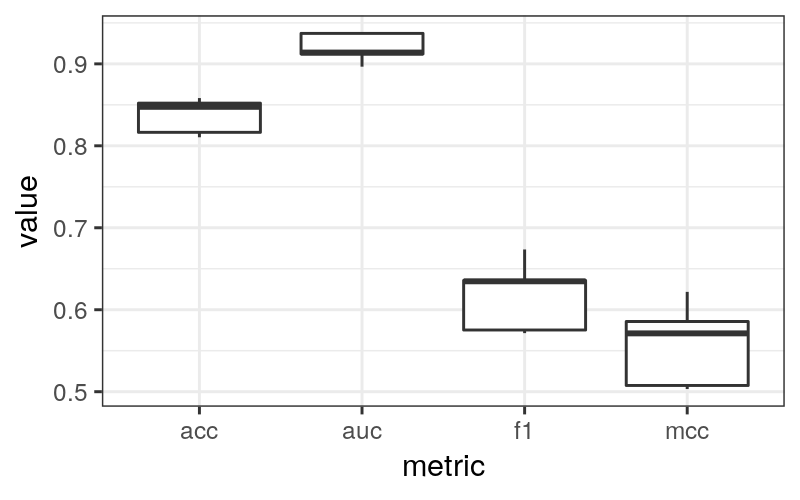

In [46]:
# performance
cls_perf(res)

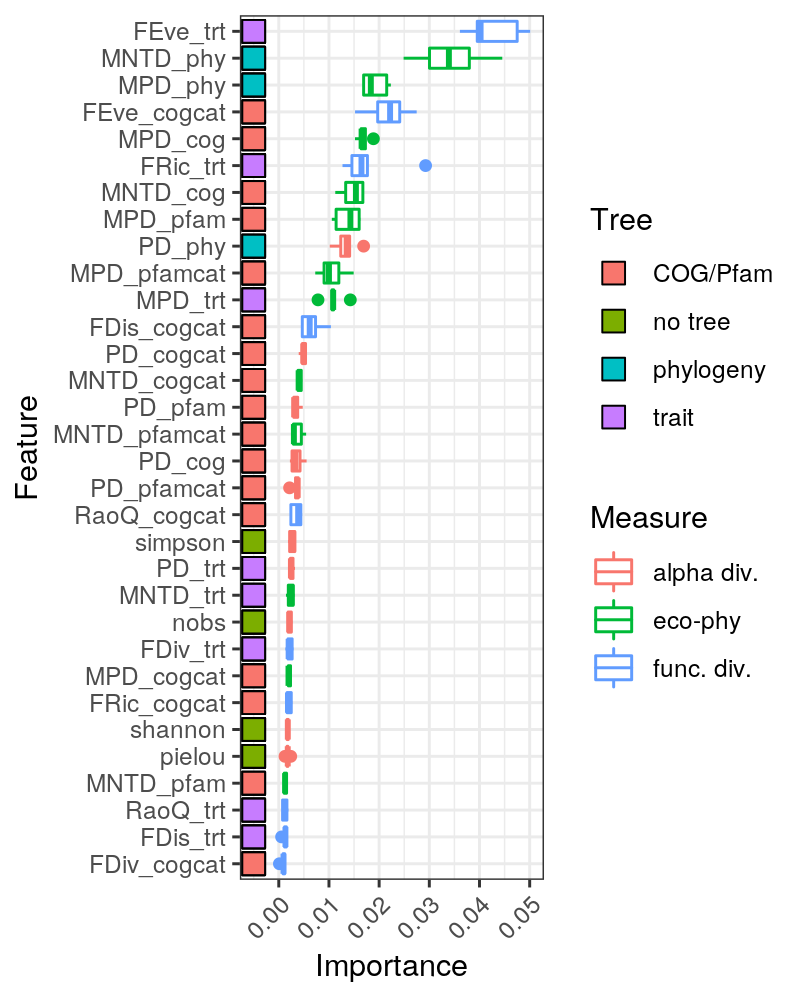

In [47]:
# plotting the most important features
feat_imp = get_feat_imp(res)
p = plot_feat_imp(feat_imp, y_offset=-0.005)
p.dims(4,5)
plot(p)

# Gender

In [48]:
target = 'gender'
measures = list(auc, acc, mcc, f1)
cv_iters = 5

In [49]:
# formatting
feats_f = feats %>%
    select.(-age, -BMI, -westernized, -disease) %>%
    filter.(!is.na(gender)) %>%
    as.data.frame
rownames(feats_f) = feats_f$Sample
feats_f$Sample = NULL
feats_f

,dataset_name,gender,nobs,shannon,simpson,pielou,PD_phy,PD_trt,PD_cog,PD_cogcat,⋯,FRic_trt,FEve_trt,FDiv_trt,FDis_trt,RaoQ_trt,FRic_cogcat,FEve_cogcat,FDiv_cogcat,FDis_cogcat,RaoQ_cogcat
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A11_01_1FE,PasolliE_2018,male,233,3.576704,0.9286988,0.4375333,44.75908,38.87524,61.68524,21.51138,⋯,272.5037,0.5995822,0.6097010,5.963011,37.65130,0.01847653,0.6511332,0.8165665,0.08583902,0.009809411
A13_01_1FE,PasolliE_2018,male,250,4.438556,0.9763921,0.5429624,53.53982,43.40921,71.48026,26.68735,⋯,354.5411,0.5958887,0.7600546,6.575077,45.32233,0.01821144,0.6610448,0.7751473,0.08931799,0.010776495
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
YSZC12003_37879,XieH_2016,female,196,3.230018,0.8847015,0.3951236,36.05868,34.46728,56.48618,20.88889,⋯,233.5041,0.5772738,0.9113279,7.897687,63.98199,0.01638536,0.6212356,0.9104304,0.1774742,0.03343108
YSZC12003_37880,XieH_2016,female,267,3.703088,0.9290237,0.4529936,45.58852,45.64780,77.83160,27.07221,⋯,409.0144,0.5858364,0.8649856,7.715054,62.10955,0.01838535,0.6081258,0.7577590,0.1400746,0.02553194


In [50]:
# summary
## target
feats_f[,target] %>% table
## all features
feats_f %>% summary

.
female   male 
  1290    864 

 dataset_name          gender               nobs          shannon     
 Length:2154        Length:2154        Min.   : 47.0   Min.   :1.365  
 Class :character   Class :character   1st Qu.:240.0   1st Qu.:3.708  
 Mode  :character   Mode  :character   Median :282.0   Median :4.161  
                                       Mean   :276.4   Mean   :4.030  
                                       3rd Qu.:317.0   3rd Qu.:4.462  
                                       Max.   :484.0   Max.   :5.218  
    simpson           pielou           PD_phy          PD_trt     
 Min.   :0.4596   Min.   :0.1670   Min.   :15.57   Min.   :10.57  
 1st Qu.:0.9337   1st Qu.:0.4535   1st Qu.:44.93   1st Qu.:40.95  
 Median :0.9618   Median :0.5090   Median :54.12   Median :48.88  
 Mean   :0.9436   Mean   :0.4930   Mean   :53.96   Mean   :47.92  
 3rd Qu.:0.9752   3rd Qu.:0.5458   3rd Qu.:63.10   3rd Qu.:55.85  
 Max.   :0.9905   Max.   :0.6384   Max.   :98.11   Max.   :86.07  
     PD_cog         PD_cogcat     

## RF

In [52]:
# creating mlr task
tsk = makeClassifTask(data = feats_f %>% select(-dataset_name), 
                      target = target, 
                      blocking = feats_f$dataset_name %>% as.factor)
tsk

Supervised task: feats_f %>% select(-dataset_name)
Type: classif
Target: gender
Observations: 2154
Features:
   numerics     factors     ordered functionals 
         32           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: TRUE
Has coordinates: FALSE
Classes: 2
female   male 
  1290    864 
Positive class: female

In [53]:
# what sampling rate to use?
rate = 1/1.5
undersample(tsk, rate = rate)

Supervised task: feats_f %>% select(-dataset_name)
Type: classif
Target: gender
Observations: 1724
Features:
   numerics     factors     ordered functionals 
         32           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: TRUE
Has coordinates: FALSE
Classes: 2
female   male 
   860    864 
Positive class: female

In [54]:
## feature selection (wrapping the RF learner)
lrn = makeLearner('classif.cforest', predict.type = 'prob', ntree = 500)
lrn

Learner classif.cforest from package party
Type: classif
Name: Random forest based on conditional inference trees; Short name: cforest
Class: classif.cforest
Properties: twoclass,multiclass,prob,factors,numerics,ordered,weights,missings,featimp
Predict-Type: prob
Hyperparameters: ntree=500


In [55]:
# sampling
lrn = makeUndersampleWrapper(lrn, usw.rate = rate)
lrn

Learner classif.cforest.undersampled from package mlr,party
Type: classif
Name: ; Short name: 
Class: UndersampleWrapper
Properties: numerics,factors,ordered,missings,weights,prob,twoclass,multiclass,featimp
Predict-Type: prob
Hyperparameters: ntree=500,usw.rate=0.667


In [56]:
## evaluation 
parallelStartMulticore(cpus=threads, level = 'mlr.resample')
rs = makeResampleDesc('CV', iters = cv_iters)
res = resample(lrn, tsk, 
               resampling = rs,  
               models = TRUE,
               measures = measures)
parallelStop()

Starting parallelization in mode=multicore with cpus=8.

Resampling: cross-validation

Measures:             auc       acc       mcc       f1        

Mapping in parallel: mode = multicore; level = mlr.resample; cpus = 8; elements = 5.




Aggregated Result: auc.test.mean=0.6836870,acc.test.mean=0.6318556,mcc.test.mean=0.2585316,f1.test.mean=0.6751977




Stopped parallelization. All cleaned up.



### Performance

In [57]:
df.dims(30)
perf_res[['gender_RF']] = res$measures.test
res$measures.test
df.dims()

iter,auc,acc,mcc,f1
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.6795799,0.6403712,0.2781441,0.6893788
2,0.6713165,0.6287703,0.2473623,0.6774194
3,0.6883780,0.6055684,0.2283487,0.6351931
4,0.7048040,0.6488372,0.2869041,0.6873706
5,0.6743566,0.6357309,0.2518986,0.6866267


--AUC--
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6713  0.6744  0.6796  0.6837  0.6884  0.7048 
--F1--
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6352  0.6774  0.6866  0.6752  0.6874  0.6894 
--plot--


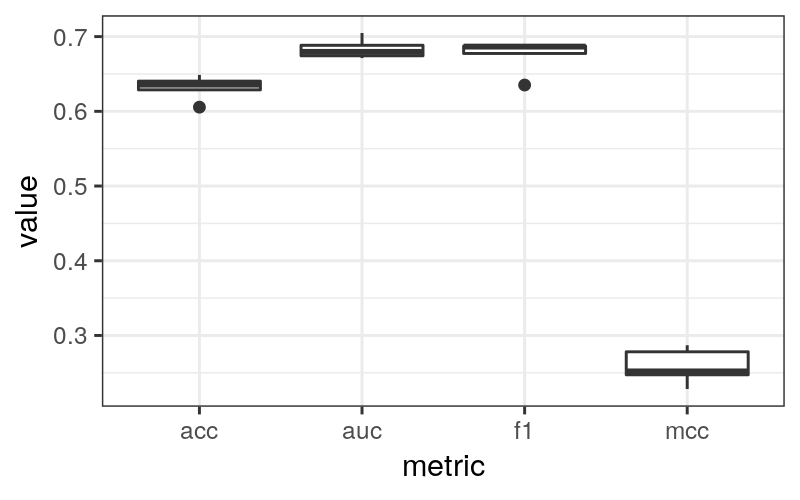

In [58]:
# performance
cls_perf(res)

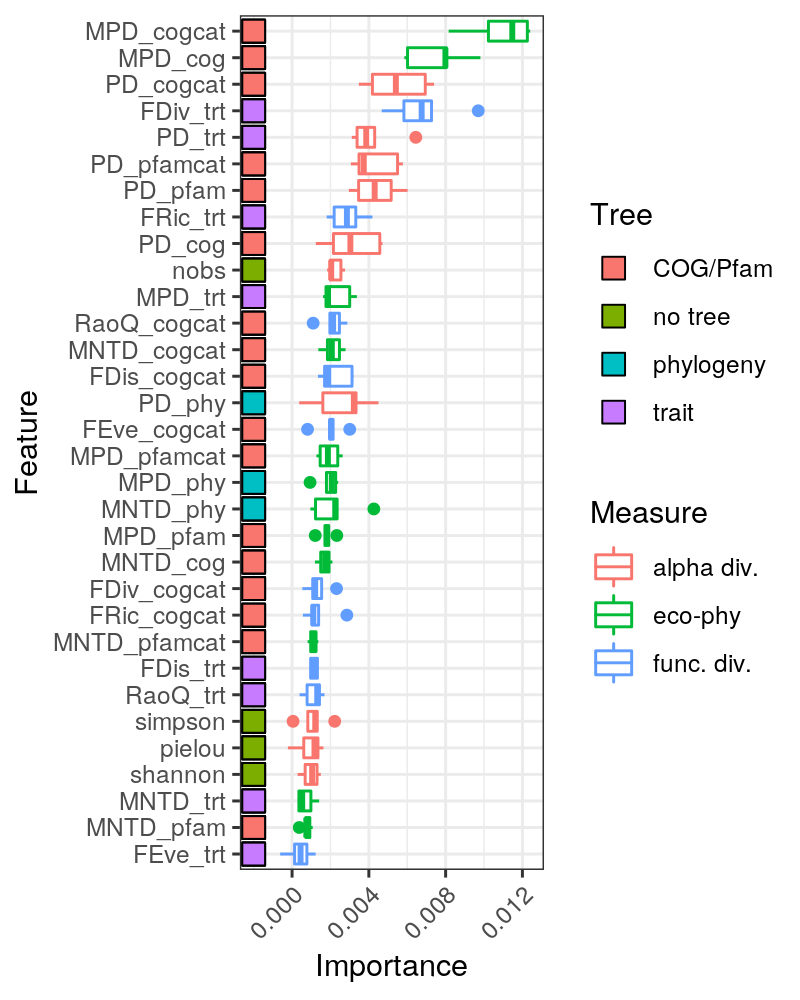

In [59]:
# plotting the most important features
feat_imp = get_feat_imp(res)
p = plot_feat_imp(feat_imp, y_offset=-0.002)
p.dims(4,5)
plot(p)

# Disease

In [60]:
target = 'disease'
measures = list(auc, acc, mcc, f1)
cv_iters = 5

In [61]:
# formatting
feats_f = feats %>%
    select.(-age, -BMI, -westernized, -gender) %>%
    filter.(!is.na(disease)) %>%
    as.data.frame
rownames(feats_f) = feats_f$Sample
feats_f$Sample = NULL
feats_f

,dataset_name,disease,nobs,shannon,simpson,pielou,PD_phy,PD_trt,PD_cog,PD_cogcat,⋯,FRic_trt,FEve_trt,FDiv_trt,FDis_trt,RaoQ_trt,FRic_cogcat,FEve_cogcat,FDiv_cogcat,FDis_cogcat,RaoQ_cogcat
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,PasolliE_2018,healthy,232,3.888802,0.9507426,0.4757117,55.94272,43.94092,73.48643,28.29848,⋯,405.3489,0.6305880,0.7290097,6.973794,52.75731,0.01801202,0.6300578,0.8226669,0.1390624,0.02458852
A02_01_1FE,PasolliE_2018,healthy,176,3.418777,0.8891672,0.4182143,40.24502,31.18437,50.07578,20.65005,⋯,315.4350,0.5794583,0.8070891,6.341048,45.50104,0.01696774,0.6244829,0.8734180,0.1164369,0.01988324
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,LiJ_2017,healthy,272,3.612832,0.8932187,0.4419526,53.11264,46.47031,88.09736,34.25477,⋯,243.02318,0.5773991,0.8391111,5.956270,37.65335,0.01740735,0.6201435,0.6753169,0.06340579,0.005202252
scavenger.11.60.0,CosteaPI_2017,healthy,210,3.891553,0.9557596,0.4760482,37.27697,35.63946,64.59389,22.62152,⋯,99.81046,0.5403505,0.5274329,5.515369,31.73968,0.01272163,0.5382319,0.7079228,0.07027430,0.005815837


In [62]:
# summary
## target
feats_f[,target] %>% table
## all features
feats_f %>% summary

.
diseased  healthy 
     653     2102 

 dataset_name         disease               nobs          shannon      
 Length:2755        Length:2755        Min.   : 23.0   Min.   :0.7248  
 Class :character   Class :character   1st Qu.:230.0   1st Qu.:3.5866  
 Mode  :character   Mode  :character   Median :272.0   Median :4.0784  
                                       Mean   :267.3   Mean   :3.9487  
                                       3rd Qu.:309.0   3rd Qu.:4.4370  
                                       Max.   :469.0   Max.   :5.1786  
    simpson           pielou            PD_phy           PD_trt      
 Min.   :0.2267   Min.   :0.08866   Min.   : 8.175   Min.   : 5.864  
 1st Qu.:0.9243   1st Qu.:0.43874   1st Qu.:42.750   1st Qu.:38.835  
 Median :0.9580   Median :0.49891   Median :51.759   Median :46.866  
 Mean   :0.9356   Mean   :0.48304   Mean   :51.951   Mean   :46.068  
 3rd Qu.:0.9745   3rd Qu.:0.54277   3rd Qu.:61.176   3rd Qu.:54.341  
 Max.   :0.9905   Max.   :0.63349   Max.   :93.614   Max.   :83.860  
     P

## RF

In [63]:
# creating mlr task
tsk = makeClassifTask(data = feats_f %>% select(-dataset_name), 
                      target = target, 
                      blocking = feats_f$dataset_name %>% as.factor)
tsk

Supervised task: feats_f %>% select(-dataset_name)
Type: classif
Target: disease
Observations: 2755
Features:
   numerics     factors     ordered functionals 
         32           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: TRUE
Has coordinates: FALSE
Classes: 2
diseased  healthy 
     653     2102 
Positive class: diseased

In [64]:
# what sampling rate to use?
rate = 1/3
undersample(tsk, rate = rate)

Supervised task: feats_f %>% select(-dataset_name)
Type: classif
Target: disease
Observations: 1354
Features:
   numerics     factors     ordered functionals 
         32           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: TRUE
Has coordinates: FALSE
Classes: 2
diseased  healthy 
     653      701 
Positive class: diseased

In [65]:
## feature selection (wrapping the RF learner)
lrn = makeLearner('classif.cforest', predict.type = 'prob', ntree = 500)
lrn

Learner classif.cforest from package party
Type: classif
Name: Random forest based on conditional inference trees; Short name: cforest
Class: classif.cforest
Properties: twoclass,multiclass,prob,factors,numerics,ordered,weights,missings,featimp
Predict-Type: prob
Hyperparameters: ntree=500


In [66]:
# sampling
lrn = makeUndersampleWrapper(lrn, usw.rate = rate)
lrn

Learner classif.cforest.undersampled from package mlr,party
Type: classif
Name: ; Short name: 
Class: UndersampleWrapper
Properties: numerics,factors,ordered,missings,weights,prob,twoclass,multiclass,featimp
Predict-Type: prob
Hyperparameters: ntree=500,usw.rate=0.333


In [67]:
## evaluation 
parallelStartMulticore(cpus=threads, level = 'mlr.resample')
rs = makeResampleDesc('CV', iters = cv_iters)
res = resample(lrn, tsk, 
               resampling = rs,  
               models = TRUE,
               measures = measures)
parallelStop()

Starting parallelization in mode=multicore with cpus=8.

Resampling: cross-validation

Measures:             auc       acc       mcc       f1        

Mapping in parallel: mode = multicore; level = mlr.resample; cpus = 8; elements = 5.




Aggregated Result: auc.test.mean=0.8174075,acc.test.mean=0.7553539,mcc.test.mean=0.4316684,f1.test.mean=0.5799892




Stopped parallelization. All cleaned up.



### Performance

In [68]:
df.dims(30)
perf_res[['disease_RF']] = res$measures.test
res$measures.test
df.dims()

iter,auc,acc,mcc,f1
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.7891493,0.7422868,0.3822846,0.5534591
2,0.8202108,0.7332123,0.4209296,0.5739130
3,0.8180777,0.7676951,0.4451838,0.5870968
4,0.8222556,0.7622505,0.4355949,0.5867508
5,0.8373438,0.7713249,0.4743488,0.5987261


--AUC--
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7891  0.8181  0.8202  0.8174  0.8223  0.8373 
--F1--
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.5535  0.5739  0.5868  0.5800  0.5871  0.5987 
--plot--


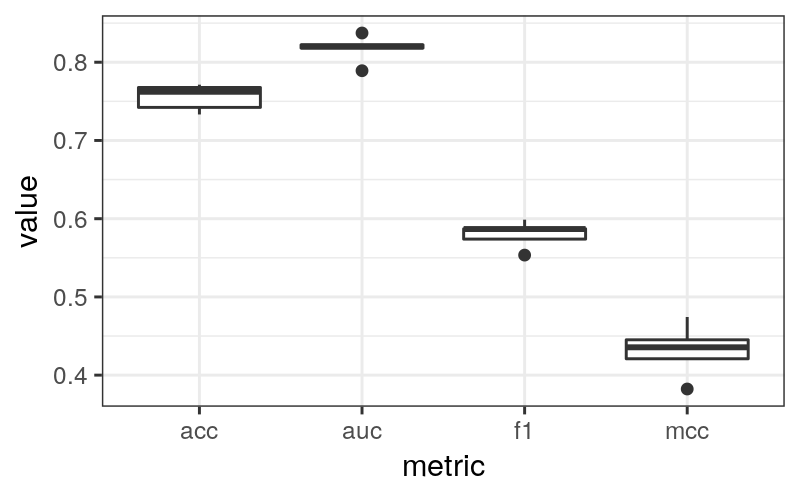

In [69]:
# performance
cls_perf(res)

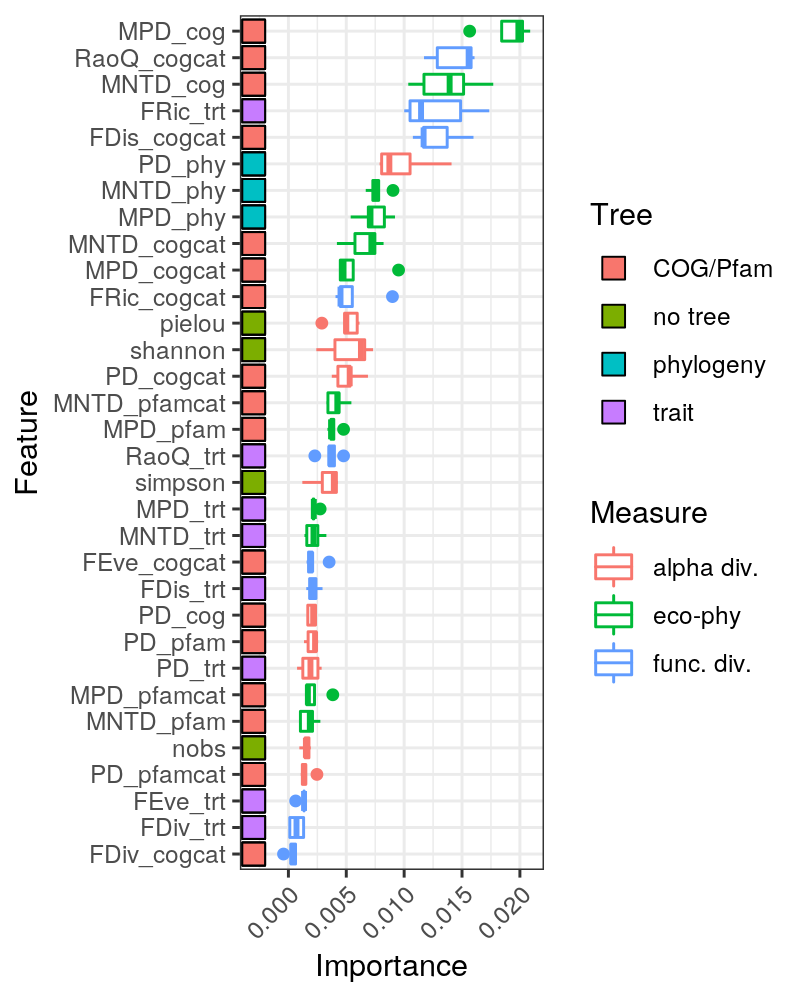

In [70]:
# plotting the most important features
feat_imp = get_feat_imp(res)
p = plot_feat_imp(feat_imp, y_offset=-0.003)
p.dims(4,5)
plot(p)

# Performance summary

In [77]:
# formatting
perf_res_f = perf_res %>%
    rbindlist(use.names=TRUE, idcol='dataset') %>%
    separate.(dataset, c('target', 'model'), sep='_') %>%
    filter.(model == 'RF') %>%
    select.(iter, auc, f1, target) %>%
    pivot_longer.(cols=c(auc, f1), names_to='measure', values_to='value') 
perf_res_f

iter,target,measure,value
<int>,<chr>,<chr>,<dbl>
1,westernized,auc,0.8965192
2,westernized,auc,0.9371493
⋮,⋮,⋮,⋮
4,disease,f1,0.5867508
5,disease,f1,0.5987261


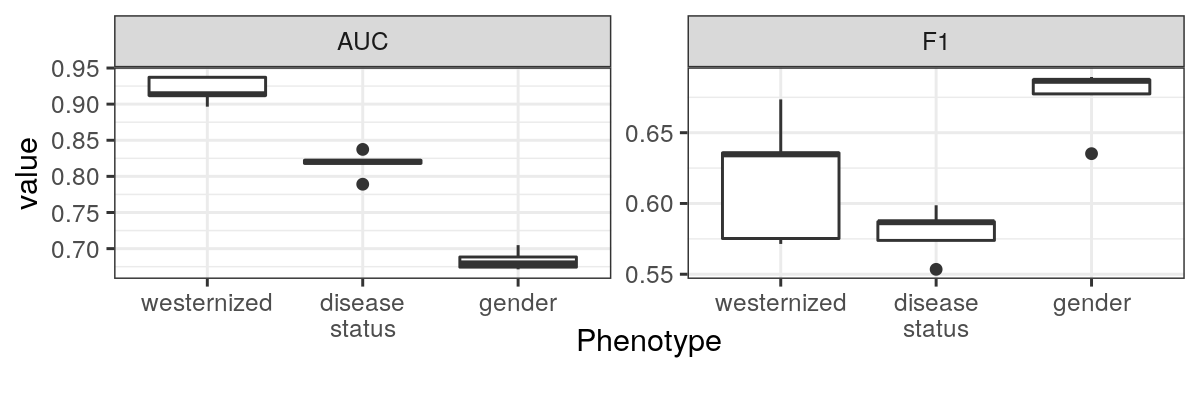

In [78]:
# plotting
p = perf_res_f %>%
    mutate.(target = ifelse(target == 'disease', 'disease\nstatus', target)) %>%
    mutate.(measure = case_when.(measure == 'auc' ~ 'AUC',
                                 measure == 'f1' ~ 'F1')) %>%
    mutate.(mean_value = mean(value),
            .by=c(target, measure)) %>%
    mutate.(target = target %>% reorder(-mean_value)) %>%
    ggplot(aes(target, value)) +
    geom_boxplot() +
    labs(x='Phenotype') +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.title.x = element_text(vjust=4)
    )
p.dims(6,2)
plot(p)

#### Writing table

In [79]:
F = file.path(work_dir, 'alpha-div_ml_dsBlock_performance.tsv')
write_table(perf_res_f, F)

File written: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/ML//alpha-div_ml_dsBlock_performance.tsv 


# sessionInfo

In [80]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 18.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ebio/abt3_projects/Anxiety_Twins_Metagenomes/envs/tidyverse-ML2/lib/libopenblasp-r0.3.12.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] parallelMap_1.5.0   randomForest_4.6-14 mlr_2.18.0         
 [4] ParamHelpers_1.14   Boruta_7.0.0        LeyLabRMisc_0.1.8  
 [7] doParallel_1.0.16   iterators_1.0.13    foreach_1.5.1      
[10] tidytable_0.5.8     data.table_1.13.6   ggplot2_3.3.3      
[